DATA WRANGLING:

In [132]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

1. OVERVIEW

In [134]:
df = pd.read_csv("./COVID_dataset.csv")
df.head(10)

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,1,1,1,3/5/20,97,1,65.0,2,2.0,...,2,2.0,1,2,2.0,2,2,2.0,3,97
1,2,1,2,1,3/6/20,97,1,72.0,97,2.0,...,2,2.0,1,2,2.0,1,1,2.0,5,97
2,2,1,2,2,9/6/20,1,2,55.0,97,1.0,...,2,2.0,2,2,2.0,2,2,2.0,3,2
3,2,1,1,1,12/6/20,97,2,NaN,2,2.0,...,2,2.0,2,2,2.0,2,2,2.0,7,97
4,2,1,2,1,21/06/2020,97,2,NaN,97,1.0,...,2,2.0,1,2,2.0,2,2,2.0,3,97
5,2,1,1,2,9999-99-99,2,1,NaN,2,2.0,...,2,2.0,2,2,2.0,2,2,2.0,3,2
6,2,1,1,1,9999-99-99,97,2,NaN,2,2.0,...,2,2.0,2,2,2.0,2,2,2.0,3,97
7,2,1,1,1,9999-99-99,97,1,NaN,2,1.0,...,2,1.0,1,2,2.0,2,1,2.0,3,97
8,2,1,1,2,9999-99-99,2,2,NaN,2,1.0,...,2,2.0,1,2,2.0,1,2,2.0,3,2
9,2,1,1,2,9999-99-99,2,2,25.0,2,2.0,...,2,2.0,2,2,2.0,2,2,2.0,3,2


In [135]:
df.shape

(1048575, 21)

The dataset was provided by the Mexican government. This dataset contains an enormous number of anonymized patient-related information including pre-conditions. The raw dataset consists of 21 unique features and 1,048,575 unique patients. In the Boolean features, 1 means "yes" and 2 means "no". values as 97 and 99 are missing data.

sex: 1 for female and 2 for male.

age: of the patient.

classification: covid test findings. Values 1-3 mean that the patient was diagnosed with covid in different
degrees. 4 or higher means that the patient is not a carrier of covid or that the test is inconclusive.

patient type: type of care the patient received in the unit. 1 for 
returned home and 2 for hospitalization.

pneumonia: whether the patient already have air sacs inflammation or not.

pregnancy: whether the patient is pregnant or not.

diabetes: whether the patient has diabetes or not.

copd: Indicates whether the patient has Chronic obstructive pulmonary 
disease or not.

asthma: whether the patient has asthma or not.

inmsupr: whether the patient is immunosuppressed or not.

hypertension: whether the patient has hypertension or not.

cardiovascular: whether the patient has heart or blood vessels related disease.

renal chronic: whether the patient has chronic renal disease or not.

other disease: whether the patient has other disease or not.

obesity: whether the patient is obese or not.

tobacco: whether the patient is a tobacco user.

usmr: Indicates whether the patient treated medical units of the first, second or third level.

medical unit: type of institution of the National Health System that provided the care.

intubed: whether the patient was connected to the ventilator.

icu: Indicates whether the patient had been admitted to an Intensive Care Unit.

date died: If the patient died indicate the date of death, and 9999-99-99 otherwise.

1.1 DATA TYPES

In [136]:
df.dtypes

USMER                     int64
MEDICAL_UNIT              int64
SEX                       int64
PATIENT_TYPE              int64
DATE_DIED                object
INTUBED                   int64
PNEUMONIA                 int64
AGE                     float64
PREGNANT                  int64
DIABETES                float64
COPD                      int64
ASTHMA                    int64
INMSUPR                 float64
HIPERTENSION              int64
OTHER_DISEASE             int64
CARDIOVASCULAR          float64
OBESITY                   int64
RENAL_CHRONIC             int64
TOBACCO                 float64
CLASIFFICATION_FINAL      int64
ICU                       int64
dtype: object

1.2 UNIQUE VALUES

In [137]:
for col in df.columns:
    print(col, sorted(df[col].dropna().unique())[:20])  

USMER [1, 2]
MEDICAL_UNIT [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
SEX [1, 2]
PATIENT_TYPE [1, 2]
DATE_DIED ['1/1/21', '1/2/20', '1/2/21', '1/3/20', '1/4/20', '1/4/21', '1/5/20', '1/5/21', '1/6/20', '1/7/20', '1/8/20', '1/9/20', '10/1/20', '10/1/21', '10/10/20', '10/2/20', '10/2/21', '10/3/20', '10/3/21', '10/4/20']
INTUBED [1, 2, 97, 99, 500]
PNEUMONIA [1, 2, 99]
AGE [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0]
PREGNANT [1, 2, 97, 98]
DIABETES [1.0, 2.0, 98.0]
COPD [1, 2, 98]
ASTHMA [1, 2, 98]
INMSUPR [1.0, 2.0, 98.0]
HIPERTENSION [1, 2, 98]
OTHER_DISEASE [1, 2, 98]
CARDIOVASCULAR [1.0, 2.0, 98.0]
OBESITY [1, 2, 98]
RENAL_CHRONIC [1, 2, 98]
TOBACCO [1.0, 2.0, 98.0]
CLASIFFICATION_FINAL [1, 2, 3, 4, 5, 6, 7]
ICU [1, 2, 97, 99]


-> not every Value is in the right data type: switch to Int:

In [138]:
df["AGE"] = df["AGE"].astype("Int64")
df["DIABETES"] = df["DIABETES"].astype("Int64")
df["INMSUPR"] = df["INMSUPR"].astype("Int64")
df["CARDIOVASCULAR"] = df["CARDIOVASCULAR"].astype("Int64")
df["TOBACCO"] = df["TOBACCO"].astype("Int64")

1.3 CHANGING DATE_DIED TO PD DATETIME

In [139]:
df["DATE_DIED"].nunique()

401

In [140]:
df["DATE_DIED"].unique()

array(['3/5/20', '3/6/20', '9/6/20', '12/6/20', '21/06/2020',
       '9999-99-99', '26/02/2020', '5/4/20', '8/5/20', '20/05/2020',
       '17/07/2020', '13/01/2020', '22/01/2020', '29/01/2020',
       '13/02/2020', '18/02/2020', '19/02/2020', '20/02/2020',
       '24/02/2020', '4/3/20', '7/3/20', '12/3/20', '14/03/2020',
       '18/03/2020', '27/03/2020', '28/03/2020', '29/03/2020', '2/4/20',
       '6/4/20', '7/4/20', '8/4/20', '9/4/20', '10/4/20', '11/4/20',
       '12/4/20', '13/04/2020', '14/04/2020', '15/04/2020', '16/04/2020',
       '17/04/2020', '18/04/2020', '20/04/2020', '21/04/2020',
       '22/04/2020', '23/04/2020', '24/04/2020', '25/04/2020',
       '26/04/2020', '27/04/2020', '28/04/2020', '29/04/2020',
       '30/04/2020', '1/5/20', '2/5/20', '4/5/20', '5/5/20', '6/5/20',
       '7/5/20', '9/5/20', '10/5/20', '11/5/20', '12/5/20', '13/05/2020',
       '14/05/2020', '15/05/2020', '16/05/2020', '17/05/2020',
       '18/05/2020', '19/05/2020', '21/05/2020', '22/05/2020',
 

there are 401 different death dates over 2 years

In [141]:
df_date = df.copy()

# Replace sentinel
df_date["DATE_DIED"] = df_date["DATE_DIED"].replace("9999-99-99", pd.NA)

# Convert to string dtype (critical!)
s = df_date["DATE_DIED"].astype("string")

# Masks without NA
mask_long  = s.str.match(r"^\d{1,2}/\d{1,2}/\d{4}$", na=False)
mask_short = s.str.match(r"^\d{1,2}/\d{1,2}/\d{2}$",  na=False)

# Empty datetime Series
parsed = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns]")

# Parse long format
parsed.loc[mask_long] = pd.to_datetime(
    s[mask_long], format="%d/%m/%Y", errors="coerce"
)

# Parse short format
parsed.loc[mask_short] = pd.to_datetime(
    s[mask_short], format="%d/%m/%y", errors="coerce"
)

df_date["DATE_DIED"] = parsed


All the dates were changed to pd datetime and placeholders (9999-99-99) were replaced with NaT

In [142]:
df_date["DATE_DIED"].min(), df_date["DATE_DIED"].max()

(Timestamp('2020-01-02 00:00:00'), Timestamp('2021-05-02 00:00:00'))

First and last Death

2. SORTING DATA

In [143]:
df_sorted = df_date.sort_values(by=["DATE_DIED", "CLASIFFICATION_FINAL"])
df_sorted.head(10)

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
19495,2,4,1,2,2020-01-02,99,99,65,2,2,...,2,1,2,2,2,2,2,2,7,99
444584,1,12,2,2,2020-01-03,1,1,47,97,2,...,2,2,2,2,2,2,2,2,5,1
19496,1,4,2,2,2020-01-03,99,99,32,97,2,...,2,2,2,2,2,2,2,2,7,99
19497,1,4,1,2,2020-01-03,99,99,67,2,1,...,2,2,2,2,2,1,2,2,7,99
19498,1,4,2,2,2020-01-03,99,99,15,97,2,...,1,2,2,2,2,2,2,2,7,99
382619,1,8,1,2,2020-01-03,99,99,67,2,2,...,1,1,1,2,2,1,2,2,7,99
19499,1,4,1,2,2020-01-04,99,99,46,2,2,...,2,2,2,2,2,2,2,2,7,99
19500,1,4,1,2,2020-01-05,99,99,56,2,1,...,2,2,2,2,2,1,2,2,7,99
444585,1,12,2,2,2020-01-05,2,2,1,97,2,...,2,2,2,2,2,2,2,2,7,2
19501,1,4,2,2,2020-01-06,99,99,84,97,2,...,2,2,2,2,2,2,2,2,7,99


sorted for DATE_DIED and CLASIFFICATION_FINAL

3. DUPLICATES

In [144]:
df_sorted.duplicated().sum()

812045

812045 Duplicates?! Realy that many?

In [145]:
df_dups = df_sorted[df_sorted.duplicated(keep=False)]
df_dups.head(10)

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
20240,1,4,2,2,2020-04-03,2,1,67,97,1,...,2,2,1,2,2,2,2,2,7,2
20247,1,4,2,2,2020-04-03,2,1,67,97,1,...,2,2,1,2,2,2,2,2,7,2
20675,1,4,2,2,2020-04-11,2,1,45,97,2,...,2,2,2,2,2,2,2,2,3,2
20676,1,4,2,2,2020-04-11,2,1,45,97,2,...,2,2,2,2,2,2,2,2,3,2
21565,1,4,2,2,2020-04-20,1,1,38,97,2,...,2,2,2,2,2,2,2,2,3,2
21616,1,4,2,2,2020-04-20,1,1,38,97,2,...,2,2,2,2,2,2,2,2,3,2
21747,1,4,2,2,2020-04-21,1,1,68,97,2,...,2,2,2,2,2,2,2,2,3,2
21780,1,4,2,2,2020-04-21,1,1,68,97,2,...,2,2,2,2,2,2,2,2,3,2
22051,1,4,2,2,2020-04-23,1,1,44,97,1,...,2,2,2,2,2,2,2,2,3,2
22088,1,4,2,2,2020-04-23,1,1,44,97,1,...,2,2,2,2,2,2,2,2,3,2


these are some rows that have duplicates. same values over 21 features? --> can not be must be duplicates

In [146]:
group_sizes = df_sorted.groupby(df_sorted.columns.tolist()).size()
group_sizes.value_counts().sort_index()

1    75035
2      881
3       45
4        2
Name: count, dtype: int64

In [147]:
example_key = group_sizes.sort_values(ascending=False).index[0]
example_rows = df_sorted[(df_sorted == pd.Series(example_key, index=df_sorted.columns)).all(axis=1)]
example_rows


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
466415,1,12,2,2,2020-07-16,2,1,55,97,2,...,2,2,2,2,2,2,2,2,3,2
466425,1,12,2,2,2020-07-16,2,1,55,97,2,...,2,2,2,2,2,2,2,2,3,2
466528,1,12,2,2,2020-07-16,2,1,55,97,2,...,2,2,2,2,2,2,2,2,3,2
466573,1,12,2,2,2020-07-16,2,1,55,97,2,...,2,2,2,2,2,2,2,2,3,2


another example...

In [148]:
dead = df_sorted[df_sorted["DATE_DIED"] != "9999-99-99"]
alive = df_sorted[df_sorted["DATE_DIED"].isna()]

dead_dups = dead.duplicated().sum()
alive_dups = alive.duplicated().sum()
dead_dups, alive_dups

(812045, 811068)

checking if only living or dead people have duplicates. --> no both groupes have duplicates

EXPLANATION: It is likely that patients who were tested more frequently were listed twice. The duplicates are being removed; it is extremely unlikely that so many lines appearing two or three times represent different individuals.

In [149]:
df_unique = df_sorted.drop_duplicates()
df_unique.shape

(236530, 21)

New Dataset has 236'530 unique data points

In [150]:
df_unique.duplicated().sum()    

0

4. DELETING PLACEHOLDERS

In [151]:
df_cleaned = df_unique.copy()

In [152]:
cols_to_convert = df_cleaned.columns.drop("DATE_DIED")

df_cleaned[cols_to_convert] = df_cleaned[cols_to_convert].astype("Int64")

In [153]:
placeholders = [97,98, 99, 500]
cols_without_age = df_unique.columns.drop("AGE")

df_cleaned[cols_without_age] = df_cleaned[cols_without_age].mask(
    df_cleaned[cols_without_age].isin(placeholders),
    pd.NA
)

In [154]:
df_cleaned.head(10)

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
19495,2,4,1,2,2020-01-02,<NA>,<NA>,65,2,2,...,2,1,2,2,2,2,2,2,7,<NA>
444584,1,12,2,2,2020-01-03,1,1,47,<NA>,2,...,2,2,2,2,2,2,2,2,5,1
19496,1,4,2,2,2020-01-03,<NA>,<NA>,32,<NA>,2,...,2,2,2,2,2,2,2,2,7,<NA>
19497,1,4,1,2,2020-01-03,<NA>,<NA>,67,2,1,...,2,2,2,2,2,1,2,2,7,<NA>
19498,1,4,2,2,2020-01-03,<NA>,<NA>,15,<NA>,2,...,1,2,2,2,2,2,2,2,7,<NA>
382619,1,8,1,2,2020-01-03,<NA>,<NA>,67,2,2,...,1,1,1,2,2,1,2,2,7,<NA>
19499,1,4,1,2,2020-01-04,<NA>,<NA>,46,2,2,...,2,2,2,2,2,2,2,2,7,<NA>
19500,1,4,1,2,2020-01-05,<NA>,<NA>,56,2,1,...,2,2,2,2,2,1,2,2,7,<NA>
444585,1,12,2,2,2020-01-05,2,2,1,<NA>,2,...,2,2,2,2,2,2,2,2,7,2
19501,1,4,2,2,2020-01-06,<NA>,<NA>,84,<NA>,2,...,2,2,2,2,2,2,2,2,7,<NA>


Placeholder replaced.

4.1 NEW COLUMNS FOR BETTER INTERPRETATION

In [155]:
df_cleaned["COVID_POSITIVE"] = df_cleaned["CLASIFFICATION_FINAL"].apply(
    lambda x: 1 if x in [1, 2, 3] else 2
)


COVID_POSITIVE = HAS A PATIENT COVID SYMPTOMPS 1 = YES; 2 = NO

In [156]:
df_cleaned["DIED"] = df_cleaned["DATE_DIED"].apply(
    lambda x: 1 if pd.notna(x) else 2
)

DIED = IF A PATIENT DIED 1 = YES; 2 = NO

In [157]:
df_cleaned["ID"] = range(1, len(df_cleaned) + 1)

ID = PATIENT ID (1 TO 236'530)

In [158]:
df_cleaned.head(10)

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU,COVID_POSITIVE,DIED,ID
19495,2,4,1,2,2020-01-02,<NA>,<NA>,65,2,2,...,2,2,2,2,2,7,<NA>,2,1,1
444584,1,12,2,2,2020-01-03,1,1,47,<NA>,2,...,2,2,2,2,2,5,1,2,1,2
19496,1,4,2,2,2020-01-03,<NA>,<NA>,32,<NA>,2,...,2,2,2,2,2,7,<NA>,2,1,3
19497,1,4,1,2,2020-01-03,<NA>,<NA>,67,2,1,...,2,2,1,2,2,7,<NA>,2,1,4
19498,1,4,2,2,2020-01-03,<NA>,<NA>,15,<NA>,2,...,2,2,2,2,2,7,<NA>,2,1,5
382619,1,8,1,2,2020-01-03,<NA>,<NA>,67,2,2,...,2,2,1,2,2,7,<NA>,2,1,6
19499,1,4,1,2,2020-01-04,<NA>,<NA>,46,2,2,...,2,2,2,2,2,7,<NA>,2,1,7
19500,1,4,1,2,2020-01-05,<NA>,<NA>,56,2,1,...,2,2,1,2,2,7,<NA>,2,1,8
444585,1,12,2,2,2020-01-05,2,2,1,<NA>,2,...,2,2,2,2,2,7,2,2,1,9
19501,1,4,2,2,2020-01-06,<NA>,<NA>,84,<NA>,2,...,2,2,2,2,2,7,<NA>,2,1,10


5. MISSING DATA

5.1 DETECTING MISSING DATA

In [159]:
df_cleaned.apply(lambda col: col.isin(["", " ", "NA", "N/A", "None", "nan", "NaN"]).sum())

USMER                   0
MEDICAL_UNIT            0
SEX                     0
PATIENT_TYPE            0
DATE_DIED               0
INTUBED                 0
PNEUMONIA               0
AGE                     0
PREGNANT                0
DIABETES                0
COPD                    0
ASTHMA                  0
INMSUPR                 0
HIPERTENSION            0
OTHER_DISEASE           0
CARDIOVASCULAR          0
OBESITY                 0
RENAL_CHRONIC           0
TOBACCO                 0
CLASIFFICATION_FINAL    0
ICU                     0
COVID_POSITIVE          0
DIED                    0
ID                      0
dtype: int64

checking if there are hidden NaN's in string format --> every Placeholder is now replaced

In [160]:
df_cleaned.isna().sum()

USMER                        0
MEDICAL_UNIT                 0
SEX                          0
PATIENT_TYPE                 0
DATE_DIED               160565
INTUBED                 105391
PNEUMONIA                 7187
AGE                          6
PREGNANT                131458
DIABETES                  2841
COPD                      2529
ASTHMA                    2506
INMSUPR                   2927
HIPERTENSION              2620
OTHER_DISEASE             4362
CARDIOVASCULAR            2604
OBESITY                   2554
RENAL_CHRONIC             2531
TOBACCO                   2739
CLASIFFICATION_FINAL         0
ICU                     105540
COVID_POSITIVE               0
DIED                         0
ID                           0
dtype: int64

In [161]:
df_cleaned.isna().sum().sum()


538360

In [162]:
total_missing_pct = df_cleaned.isna().sum().sum() / df_cleaned.size * 100
total_missing_pct


9.483645485421158

the total amount missing is 538'360 (9.5%) which is acceptable but not optimal 

In [163]:
df_cleaned[df_cleaned["AGE"].isna()]


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU,COVID_POSITIVE,DIED,ID
3,2,1,1,1,2020-06-12,<NA>,2,<NA>,2,2,...,2,2,2,2,2,7,<NA>,2,1,39034
4,2,1,2,1,2020-06-21,<NA>,2,<NA>,<NA>,1,...,2,2,2,2,2,3,<NA>,1,1,46013
5,2,1,1,2,NaT,2,1,<NA>,2,2,...,2,2,2,2,2,3,2,1,2,79741
6,2,1,1,1,NaT,<NA>,2,<NA>,2,2,...,2,2,2,2,2,3,<NA>,1,2,79742
7,2,1,1,1,NaT,<NA>,1,<NA>,2,1,...,2,2,2,1,2,3,<NA>,1,2,79743
8,2,1,1,2,NaT,2,2,<NA>,2,1,...,2,2,1,2,2,3,2,1,2,79744


5.2 WHY IS THE DATA MISSING (MAR, MNAR, MCAR)

5.2.1 ICU AND INTUBED

In ICU and Intubed are almost the same amount missing, why? Maybe only information of patients that stayed in the hospital were taken:

In [164]:
df_cleaned.groupby("PATIENT_TYPE")["ICU"].apply(lambda x: x.isna().mean())

PATIENT_TYPE
1    1.000000
2    0.041378
Name: ICU, dtype: float64

For 1 (Returned Home), all data is missing; for 2 (Hospitalized), only some data is missing. --> MAR; because patients don't go to the hospital, they also don't go to the Intensive Care Unit, therefore no value is recorded.

checking if the information was only taken for COVID pos patients:

In [165]:
df_cleaned.groupby("COVID_POSITIVE")["INTUBED"].apply(lambda x: x.isna().mean())

COVID_POSITIVE
1    0.337959
2    0.544494
Name: INTUBED, dtype: float64

no, there is no visible explanation!

Same thing for INTUBED:

In [166]:
df_cleaned.groupby("PATIENT_TYPE")["INTUBED"].apply(lambda x: x.isna().mean())

PATIENT_TYPE
1    1.000000
2    0.040287
Name: INTUBED, dtype: float64

Exactly the same outcome --> MAR

5.2.2 PREGNANT

In [167]:
df_cleaned.groupby("SEX")["PREGNANT"].apply(lambda x: x.isna().mean())

SEX
1    0.018257
2    1.000000
Name: PREGNANT, dtype: float64

in women (1) is almost nothing missing, in men (2) everything. Men did not get asked if pregnant... --> MAR 

Text(0.5, 1.0, 'Missing Values Heatmap')

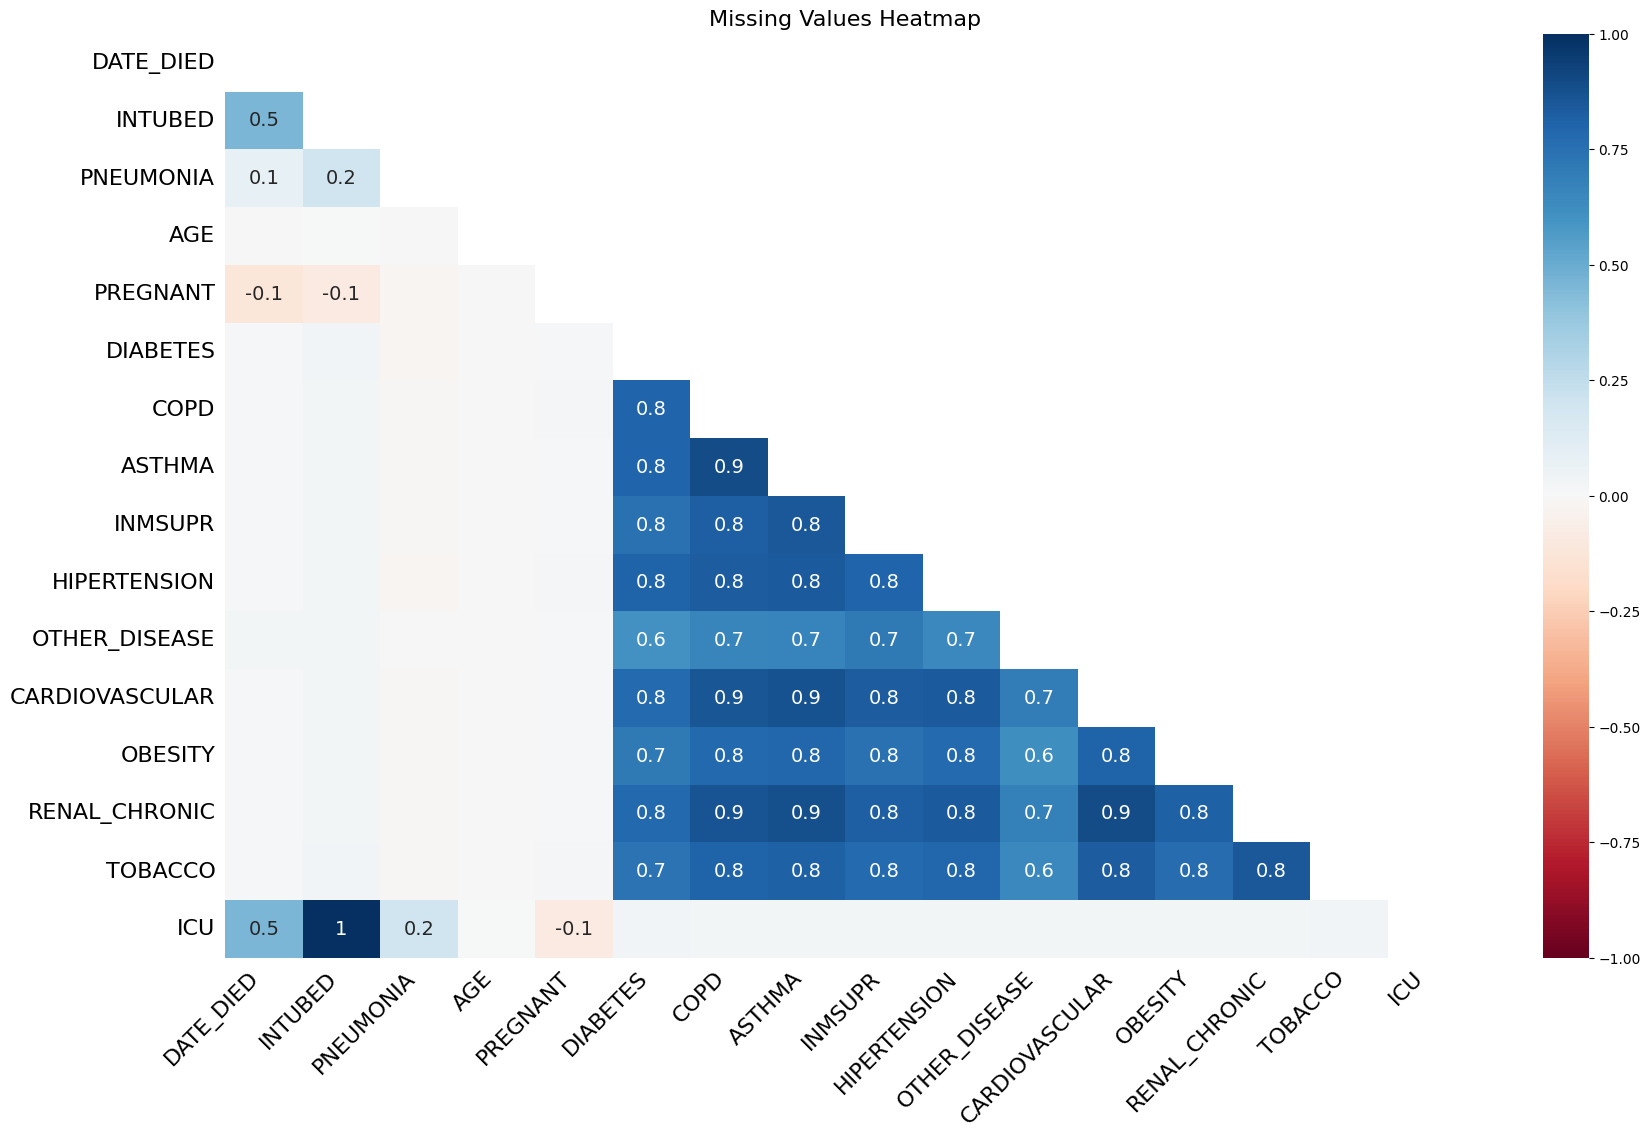

In [168]:
import missingno as msno

msno.heatmap(df_cleaned).set_title("Missing Values Heatmap", fontsize=16)


This heatmap shows how missing values co‑occur across all variables. Blue cells indicate that two variables tend to be missing at the same time, red cells indicate opposite missingness patterns, and white means no meaningful relationship. This helps identify whether missing data is random or driven by structure in the dataset.

The strongest dependency appears between INTUBED and ICU, where missingness is perfectly aligned, suggesting both variables are recorded under the same clinical conditions.

5.2.3 ALL THE COMORBIDITIES

In [169]:
missing_by_unit = df_cleaned.groupby("MEDICAL_UNIT").apply(lambda g: g.isna().mean())
missing_by_unit

C:\Users\glaro\AppData\Local\Temp\ipykernel_23508\1672838680.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_unit = df_cleaned.groupby("MEDICAL_UNIT").apply(lambda g: g.isna().mean())


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU,COVID_POSITIVE,DIED,ID
MEDICAL_UNIT,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.959677,0.814516,0.000000,0.048387,0.475806,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.814516,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.965517,0.772414,0.068966,0.000000,0.420690,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.772414,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.833649,0.610659,0.031999,0.000000,0.525588,0.003791,...,0.005575,0.004237,0.002787,0.003456,0.005129,0.0,0.610993,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.556938,0.338439,0.030926,0.000000,0.555169,0.003099,...,0.003088,0.003088,0.001961,0.003156,0.003144,0.0,0.338529,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.864961,0.641824,0.032703,0.000000,0.529032,0.001112,...,0.001557,0.001112,0.000667,0.001335,0.001335,0.0,0.641824,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.725021,0.432994,0.046766,0.000000,0.543052,0.013573,...,0.025431,0.012192,0.012144,0.011954,0.012763,0.0,0.434089,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.947090,0.623016,0.000000,0.000000,0.543651,0.010582,...,0.017196,0.011905,0.010582,0.009259,0.010582,0.0,0.623016,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.818761,0.545892,0.023451,0.000000,0.603355,0.001708,...,0.003572,0.001398,0.001242,0.001708,0.015220,0.0,0.546203,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.901306,0.533295,0.002381,0.000000,0.571099,0.026116,...,0.026694,0.023086,0.022581,0.022581,0.023231,0.0,0.533295,0.0,0.0,0.0


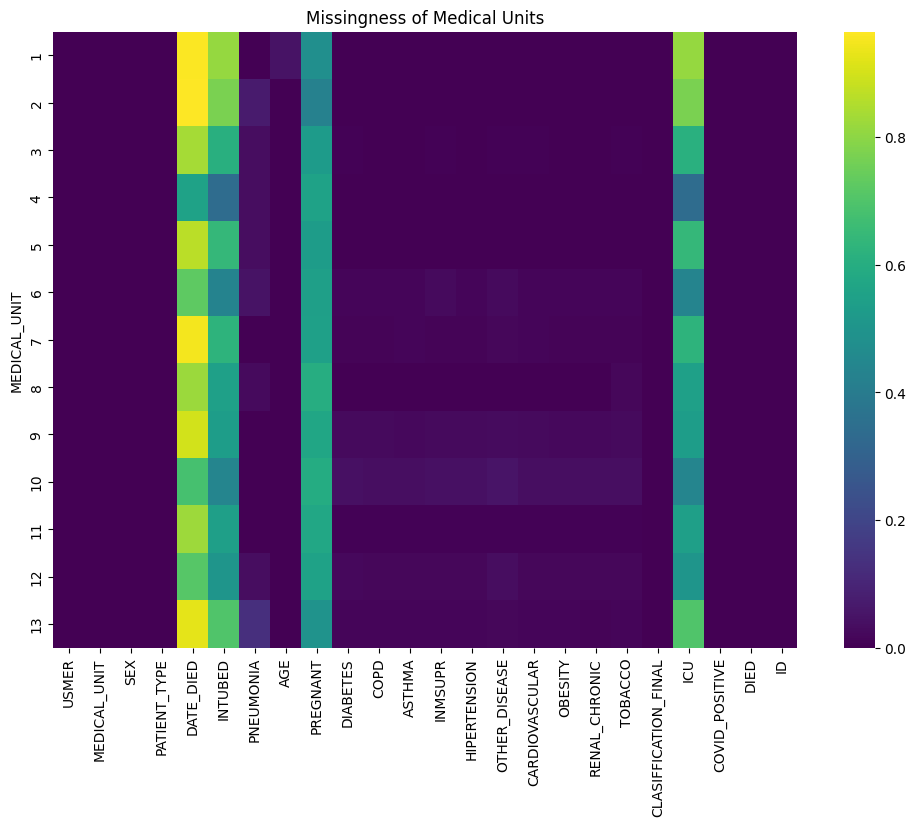

In [170]:
plt.figure(figsize=(12,8))
sns.heatmap(missing_by_unit, cmap="viridis")
plt.title("Missingness of Medical Units")
plt.show()

The comorbidity variables show a very even distribution of missingness across all medical units. Since no medical unit has systematically higher or lower missingness for these variables, the missing data pattern does not follow a clinical or structural rule. This strongly suggests that missingness in the comorbidities is Most Likely MCAR, meaning the probability of a value being missing is unrelated to the variable itself or other variables.

5.2.4 TOBACCO

There is only a small amount missing in TOBACCO but because patients can lie about their t0bacco intake it is treated as MNAR!

5.2.5 AGE

Only small amount missing --> MCAR

SUMMARY

MISSING AT RANDOM (MAR):

DATE_DIED: Many NaT values because they were originally stored as 9999‑99‑99. These represent individuals who did not die.

INTUBED: Only patients who were admitted to an Intensive Care Unit were intubated; for all others this value is missing.

PREGNANT: For men and for women without any suspicion of pregnancy, no data is recorded.

ICU: Patients treated as outpatients or without COVID have no data in this variable.

MISSING COMPLETELY AT RANDOM (MCAR):

PNEUMONIA, AGE, DIABETES, COPD, ASTHMA, INMSUPR, HYPERTENSION, OTHER_DISEASE, OBESITY, RENAL_CHRONIC.  
All have very few missing values and show no pattern across groups. This indicates that the missing data is due to non‑recording or oversight.

MISSING NOT AT RANDOM (MNAR):

TOBACCO: Patients can hide the fact they consume tobacco

For the remaining features, no values are missing.

In [171]:
missing_per_column = df_cleaned.isna().mean() * 100
missing_per_column.sort_values(ascending=False)

DATE_DIED               67.883567
PREGNANT                55.577728
ICU                     44.620133
INTUBED                 44.557139
PNEUMONIA                3.038515
OTHER_DISEASE            1.844164
INMSUPR                  1.237475
DIABETES                 1.201116
TOBACCO                  1.157993
HIPERTENSION             1.107682
CARDIOVASCULAR           1.100917
OBESITY                  1.079778
RENAL_CHRONIC            1.070055
COPD                     1.069209
ASTHMA                   1.059485
AGE                      0.002537
CLASIFFICATION_FINAL     0.000000
COVID_POSITIVE           0.000000
DIED                     0.000000
USMER                    0.000000
MEDICAL_UNIT             0.000000
PATIENT_TYPE             0.000000
SEX                      0.000000
ID                       0.000000
dtype: float64

Percentage of missing values for each column. (DATE_DIED is special because we changed placeholders to NaN's)

5.3 IMPUTATION METHODS

5.3.1 COLUMNS WITH MCAR (COMORBIDITIES)

In [172]:
cols_binary = [
    "PNEUMONIA","OTHER_DISEASE","INMSUPR","DIABETES","HIPERTENSION","CARDIOVASCULAR",
    "OBESITY","RENAL_CHRONIC","COPD","ASTHMA",
]

df_cleaned[cols_binary] = df_cleaned[cols_binary].fillna(2)

Missing values got imputed with 2 (No)

5.3.2 AGE

In [173]:
df_cleaned["AGE"].unique()

<IntegerArray>
[ 65,  47,  32,  67,  15,  46,  56,   1,  84,  82,
 ...
 110, 114, 118, 117, 121, 107, 111, 115, 113, 500]
Length: 123, dtype: Int64

there are some unnatural values? (500?)

In [174]:
df_cleaned["AGE"].min(), df_cleaned["AGE"].max()

(0, 500)

In [175]:
df_cleaned.loc[df_cleaned["AGE"] > 120, "AGE"] = np.nan

all the values above 120 got replaced by NaN (probably another placeholder)

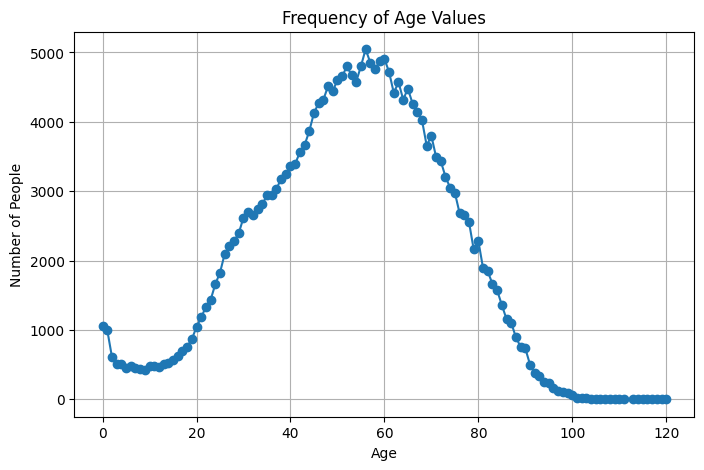

In [176]:
# Häufigkeiten berechnen
age_counts = df_cleaned["AGE"].value_counts().sort_index()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(age_counts.index, age_counts.values, marker="o")

plt.xlabel("Age")
plt.ylabel("Number of People")
plt.title("Frequency of Age Values")
plt.grid(True)

plt.show()


There are some outliers: 0 and 120 years old --> are these real people or upper/lower limits?

We decided to keep these patients: 0 year old could be tested directly after birth and up to 120 year old could be theire real age. 

In [177]:
df_cleaned["AGE"] = df_cleaned["AGE"].fillna(df_cleaned["AGE"].median())

Because of the wide spread (outliers) we decided to use median imputation

5.3.3 TOBACCO

In [178]:
df_cleaned["TOBACCO"] = df_cleaned["TOBACCO"].fillna(3)

Because of the fact that people don't want to say if they consume tobacco we imputed 3 for "unknown"

5.3.4 ICU AND INTUBED

In [179]:
df_cleaned["ICU"] = df_cleaned["ICU"].fillna(2)
df_cleaned["INTUBED"] = df_cleaned["INTUBED"].fillna(2)


ICU and INTUBED got imputed with 2 (No) because the patients with missing values were the patients that could go home that means they did not get intubed or stayed at an icu

5.3.5 PREGNANT

In [180]:
df_cleaned["PREGNANT"] = df_cleaned["PREGNANT"].fillna(2)

Pregnant got imputed with 2 (No) because the missing values are from Men

5.3.6 SUMMARY

In [181]:
missing_per_column = df_cleaned.isna().mean() * 100
missing_per_column.sort_values(ascending=False)

DATE_DIED               67.883567
USMER                    0.000000
HIPERTENSION             0.000000
DIED                     0.000000
COVID_POSITIVE           0.000000
ICU                      0.000000
CLASIFFICATION_FINAL     0.000000
TOBACCO                  0.000000
RENAL_CHRONIC            0.000000
OBESITY                  0.000000
CARDIOVASCULAR           0.000000
OTHER_DISEASE            0.000000
INMSUPR                  0.000000
MEDICAL_UNIT             0.000000
ASTHMA                   0.000000
COPD                     0.000000
DIABETES                 0.000000
PREGNANT                 0.000000
AGE                      0.000000
PNEUMONIA                0.000000
INTUBED                  0.000000
PATIENT_TYPE             0.000000
SEX                      0.000000
ID                       0.000000
dtype: float64

No missing values anymore (except DATE_DIED but for that there is a new column = DIED)

In [182]:
for col in df_cleaned.columns:
    print(col, sorted(df_cleaned[col].dropna().unique())[:20])

USMER [1, 2]
MEDICAL_UNIT [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
SEX [1, 2]
PATIENT_TYPE [1, 2]
DATE_DIED [Timestamp('2020-01-02 00:00:00'), Timestamp('2020-01-03 00:00:00'), Timestamp('2020-01-04 00:00:00'), Timestamp('2020-01-05 00:00:00'), Timestamp('2020-01-06 00:00:00'), Timestamp('2020-01-07 00:00:00'), Timestamp('2020-01-08 00:00:00'), Timestamp('2020-01-09 00:00:00'), Timestamp('2020-01-10 00:00:00'), Timestamp('2020-01-11 00:00:00'), Timestamp('2020-01-12 00:00:00'), Timestamp('2020-01-13 00:00:00'), Timestamp('2020-01-14 00:00:00'), Timestamp('2020-01-15 00:00:00'), Timestamp('2020-01-16 00:00:00'), Timestamp('2020-01-17 00:00:00'), Timestamp('2020-01-18 00:00:00'), Timestamp('2020-01-19 00:00:00'), Timestamp('2020-01-20 00:00:00'), Timestamp('2020-01-21 00:00:00')]
INTUBED [1, 2]
PNEUMONIA [1, 2]
AGE [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
PREGNANT [1, 2]
DIABETES [1, 2]
COPD [1, 2]
ASTHMA [1, 2]
INMSUPR [1, 2]
HIPERTENSION [1, 2]
OTHER_DI

no unclear unique values anymore

In [183]:
df_cleaned.head(10) 

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU,COVID_POSITIVE,DIED,ID
19495,2,4,1,2,2020-01-02,2,2,65,2,2,...,2,2,2,2,2,7,2,2,1,1
444584,1,12,2,2,2020-01-03,1,1,47,2,2,...,2,2,2,2,2,5,1,2,1,2
19496,1,4,2,2,2020-01-03,2,2,32,2,2,...,2,2,2,2,2,7,2,2,1,3
19497,1,4,1,2,2020-01-03,2,2,67,2,1,...,2,2,1,2,2,7,2,2,1,4
19498,1,4,2,2,2020-01-03,2,2,15,2,2,...,2,2,2,2,2,7,2,2,1,5
382619,1,8,1,2,2020-01-03,2,2,67,2,2,...,2,2,1,2,2,7,2,2,1,6
19499,1,4,1,2,2020-01-04,2,2,46,2,2,...,2,2,2,2,2,7,2,2,1,7
19500,1,4,1,2,2020-01-05,2,2,56,2,1,...,2,2,1,2,2,7,2,2,1,8
444585,1,12,2,2,2020-01-05,2,2,1,2,2,...,2,2,2,2,2,7,2,2,1,9
19501,1,4,2,2,2020-01-06,2,2,84,2,2,...,2,2,2,2,2,7,2,2,1,10


In [184]:
df_cleaned.shape


(236530, 24)

In [185]:
#df_cleaned.to_csv("cleaned_COVID_data.csv", index=False)

6. MODEL PREPARATION

6.1 FEATURE SELECTION

the Feature Selection is based on "statistics.ipynb"

In [186]:
df_COVID_models = df_cleaned.copy()

In [187]:
features_to_keep = [
    # Label
    "DIED","AGE", "SEX", "DIABETES", 
    "OBESITY", "HIPERTENSION", "CARDIOVASCULAR", "COPD",
    "ASTHMA", "RENAL_CHRONIC", "INMSUPR", "OTHER_DISEASE",
    "TOBACCO", "PREGNANT", "COVID_POSITIVE"
]

In [188]:
df_COVID_models = df_COVID_models[features_to_keep]

Only the Features needed for our models are kept

6.2 BINARY VALUES

In [189]:
binary_vars = [
    'SEX', 'DIABETES', 'OBESITY', 'HIPERTENSION', 'CARDIOVASCULAR',
    'COPD', 'ASTHMA', 'RENAL_CHRONIC', 'INMSUPR', 'OTHER_DISEASE',
    'DIED', 'PREGNANT', 'COVID_POSITIVE'
]

# 1 = Ja → 1, 2 = Nein → 0
for col in binary_vars:
    df_COVID_models[col] = df_COVID_models[col].replace({1: 1, 2: 0})

# TOBACCO: 1/2 → 1/0, 3 bleibt
df_COVID_models['TOBACCO']  = df_COVID_models['TOBACCO'].replace({2: 0})

# One-hot-encoding für die 3er-Kategorie
df_COVID_models = pd.get_dummies(df_COVID_models, columns=['TOBACCO'], drop_first=True)

Now all the values are recoded to binary except AGE

| Variable | Type | Coding |
| --- | --- | --- |
| AGE | continuous | unchanged |
| SEX | binary | 0 male, 1 female |
| DIABETES, OBESITY, HIPERTENSION, CARDIOVASCULAR, COPD, ASTHMA, RENAL_CHRONIC, INMSUPR, OTHER_DISEASE, COVID_POSITIVE, PREGNANT | binary | 0 no, 1 yes |
| TOBACCO | nominal (3 categories) | 0 non‑smoker, 1 smoker, 3 unknown |
| TOBACCO_1 | dummy | 1 smoker |
| TOBACCO_3 | dummy | 1 unknown |
| DIED | binary outcome | 0 survived, 1 died |

In [190]:
df_COVID_models.head(10)

,DIED,AGE,SEX,DIABETES,OBESITY,HIPERTENSION,CARDIOVASCULAR,COPD,ASTHMA,RENAL_CHRONIC,INMSUPR,OTHER_DISEASE,PREGNANT,COVID_POSITIVE,TOBACCO_1,TOBACCO_3
19495,1,65,1,0,0,0,0,0,0,0,1,0,0,0,False,False
444584,1,47,0,0,0,0,0,0,0,0,0,0,0,0,False,False
19496,1,32,0,0,0,0,0,0,0,0,0,0,0,0,False,False
19497,1,67,1,1,1,0,0,0,0,0,0,0,0,0,False,False
19498,1,15,0,0,0,0,0,0,1,0,0,0,0,0,False,False
382619,1,67,1,0,1,1,0,1,1,0,1,0,0,0,False,False
19499,1,46,1,0,0,0,0,0,0,0,0,0,0,0,False,False
19500,1,56,1,1,1,0,0,0,0,0,0,0,0,0,False,False
444585,1,1,0,0,0,0,0,0,0,0,0,0,0,0,False,False
19501,1,84,0,0,0,0,0,0,0,0,0,0,0,0,False,False


In [191]:
for col in df_COVID_models.columns:
    print(col, sorted(df_COVID_models[col].dropna().unique())[:20])

DIED [0, 1]
AGE [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
SEX [0, 1]
DIABETES [0, 1]
OBESITY [0, 1]
HIPERTENSION [0, 1]
CARDIOVASCULAR [0, 1]
COPD [0, 1]
ASTHMA [0, 1]
RENAL_CHRONIC [0, 1]
INMSUPR [0, 1]
OTHER_DISEASE [0, 1]
PREGNANT [0, 1]
COVID_POSITIVE [0, 1]
TOBACCO_1 [False, True]
TOBACCO_3 [False, True]


In [192]:
#df_COVID_models.to_csv("cleaned_COVID_data_models_both.csv", index=False)

7. COVID Pos and COVID Neg Datasets

7.1 COVID Pos

In [193]:
df_COVID_POS = df_COVID_models.copy()

In [194]:
df_COVID_POS = df_COVID_POS[df_COVID_POS["COVID_POSITIVE"] == 1]

In [195]:
df_COVID_POS.head(10) 

,DIED,AGE,SEX,DIABETES,OBESITY,HIPERTENSION,CARDIOVASCULAR,COPD,ASTHMA,RENAL_CHRONIC,INMSUPR,OTHER_DISEASE,PREGNANT,COVID_POSITIVE,TOBACCO_1,TOBACCO_3
19719,1,56,0,1,0,1,1,0,0,1,0,0,0,1,False,False
445010,1,70,1,1,0,1,1,1,0,0,1,1,0,1,False,False
341203,1,83,1,1,0,1,1,1,1,0,0,0,0,1,False,False
19952,1,74,0,0,0,1,0,0,0,0,0,0,0,1,False,False
445013,1,42,0,1,1,0,0,0,0,0,0,0,0,1,False,False
19959,1,56,0,1,1,0,0,0,0,1,0,0,0,1,False,False
19973,1,78,0,1,0,1,0,1,0,1,1,0,0,1,False,False
393024,1,61,1,1,1,1,0,0,0,0,0,1,0,1,False,False
19981,1,57,0,1,0,1,0,0,0,0,0,0,0,1,True,False
19982,1,72,0,0,0,0,0,1,0,0,0,0,0,1,False,False


7.2 COVID Neg

In [196]:
df_COVID_NEG = df_COVID_models.copy()

In [197]:
df_COVID_NEG = df_COVID_models[df_COVID_models["COVID_POSITIVE"] == 0]

In [198]:
df_COVID_NEG.head(10)

,DIED,AGE,SEX,DIABETES,OBESITY,HIPERTENSION,CARDIOVASCULAR,COPD,ASTHMA,RENAL_CHRONIC,INMSUPR,OTHER_DISEASE,PREGNANT,COVID_POSITIVE,TOBACCO_1,TOBACCO_3
19495,1,65,1,0,0,0,0,0,0,0,1,0,0,0,False,False
444584,1,47,0,0,0,0,0,0,0,0,0,0,0,0,False,False
19496,1,32,0,0,0,0,0,0,0,0,0,0,0,0,False,False
19497,1,67,1,1,1,0,0,0,0,0,0,0,0,0,False,False
19498,1,15,0,0,0,0,0,0,1,0,0,0,0,0,False,False
382619,1,67,1,0,1,1,0,1,1,0,1,0,0,0,False,False
19499,1,46,1,0,0,0,0,0,0,0,0,0,0,0,False,False
19500,1,56,1,1,1,0,0,0,0,0,0,0,0,0,False,False
444585,1,1,0,0,0,0,0,0,0,0,0,0,0,0,False,False
19501,1,84,0,0,0,0,0,0,0,0,0,0,0,0,False,False


In [199]:
df_COVID_POS.shape

(113289, 16)

In [200]:
df_COVID_NEG.shape

(123241, 16)

In [201]:
#df_COVID_POS.to_csv("cleaned_COVID_data_POS.csv", index=False)
#df_COVID_NEG.to_csv("cleaned_COVID_data_NEG.csv", index=False)

8. SPLITTING IN TRAIN- (80%) AND TEST-SET (20%)

In [202]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Target definieren
y = df_COVID_POS["DIED"]
X = df_COVID_POS.drop(columns=["DIED"])

# 80/20 Split
X_train_pos, X_test_pos, y_train_pos, y_test_pos = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train_pos = X_train_pos.drop(columns=["COVID_POSITIVE"])
X_test_pos = X_test_pos.drop(columns=["COVID_POSITIVE"])

# Speichern
#X_train_pos.to_csv("X_train_pos.csv", index=False)
#X_test_pos.to_csv("X_test_pos.csv", index=False)
#y_train_pos.to_csv("y_train_pos.csv", index=False)
#y_test_pos.to_csv("y_test_pos.csv", index=False)


In [203]:
X_train_pos.shape, y_train_pos.shape, X_test_pos.shape, y_test_pos.shape

((90631, 14), (90631,), (22658, 14), (22658,))

In [204]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Target definieren
y = df_COVID_NEG["DIED"]
X = df_COVID_NEG.drop(columns=["DIED"])

# 80/20 Split
X_train_neg, X_test_neg, y_train_neg, y_test_neg = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train_neg = X_train_neg.drop(columns=["COVID_POSITIVE"])
X_test_neg = X_test_neg.drop(columns=["COVID_POSITIVE"])

# Speichern
#X_train_neg.to_csv("X_train_neg.csv", index=False)
#X_test_neg.to_csv("X_test_neg.csv", index=False)
#y_train_neg.to_csv("y_train_neg.csv", index=False)
#y_test_neg.to_csv("y_test_neg.csv", index=False)

In [205]:
X_train_neg.shape, y_train_neg.shape, X_test_neg.shape, y_test_neg.shape

((98592, 14), (98592,), (24649, 14), (24649,))

NOW WE ARE READY TO TRAIN OUR MODELS!